In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your files are saved as dgp.py and synth.py in the same directory
from core.dgp import ARProcess, ARGARCHProcess, IIDProcess, NormalInnov, StudentTInnov, WithOutliers
from core.synth import TrajectorySpec, SyntheticGenerator

def plot_series(df):
    
    # 3. Plotting setup
    dgps = df.index.get_level_values("dgp_name").unique()
    k = len(dgps)

    # Create a figure with k rows and 2 columns (Time Series + Distribution)
    fig, axes = plt.subplots(
        nrows=k, 
        ncols=2, 
        figsize=(14, 2.5 * k), 
        gridspec_kw={'width_ratios': [3, 1]},
        layout="tight"
    )

    # Extract axes columns for shared limits
    ax_ts = axes[:, 0]  # Time series column
    ax_dist = axes[:, 1] # Distribution column

    # Force shared axes manually across columns
    for i in range(1, k):
        ax_ts[i].sharex(ax_ts[0])
        ax_ts[i].sharey(ax_ts[0])
        ax_dist[i].sharex(ax_dist[0])
        ax_dist[i].sharey(ax_dist[0])

    # 4. Populate the subplots
    for i, dgp_name in enumerate(dgps):
        # Extract the single trajectory (traj_id = 0)
        series = df.xs((dgp_name, 0), level=("dgp_name", "traj_id"))["value"].values
        
        # Left: Time Series Plot
        ax_ts[i].plot(series, color='navy', linewidth=0.8, alpha=0.8)
        ax_ts[i].set_title(f"Time Series: {dgp_name}", loc='left')
        ax_ts[i].grid(True, alpha=0.3)
        ax_ts[i].axhline(0, color='black', linewidth=0.8, linestyle='--')
        
        # Right: Histogram / KDE Plot
        sns.histplot(series, ax=ax_dist[i], kde=True, color='darkorange', stat='density', bins=40)
        ax_dist[i].set_title("Distribution", loc='left')
        ax_dist[i].grid(True, alpha=0.3)

        # Hide x-labels except for the bottom row to keep it clean
        if i < k - 1:
            ax_ts[i].tick_params(labelbottom=False)
            ax_dist[i].tick_params(labelbottom=False)

    plt.show()

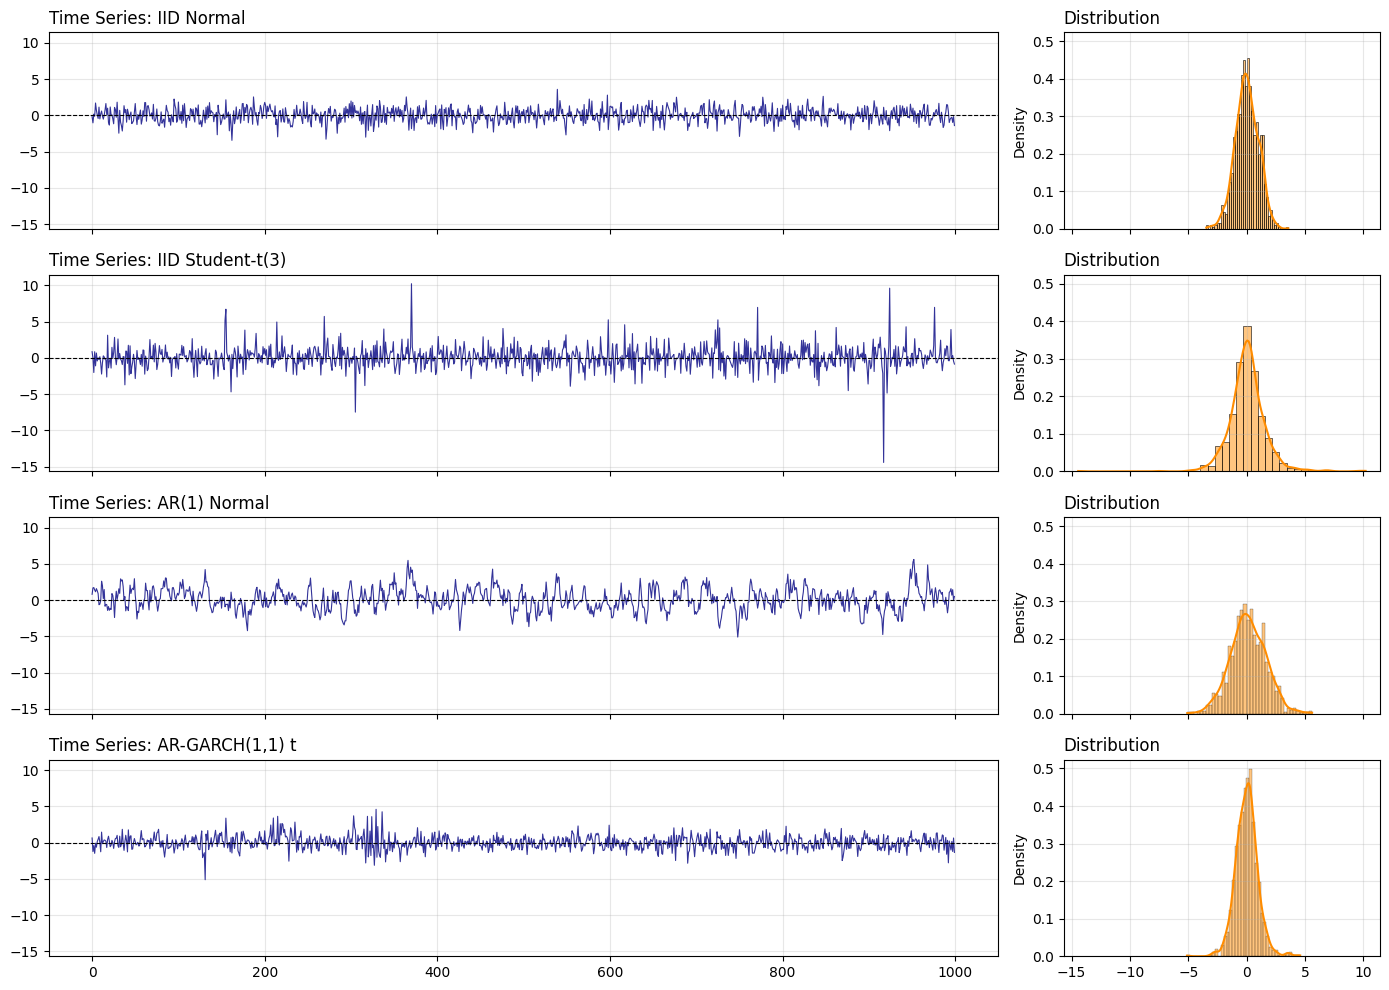

In [3]:


# 1. Define the specifications
# We use a low degrees-of-freedom for Student-t (df=3) to make the fat tails highly visible.
specs = [
    TrajectorySpec(IIDProcess(NormalInnov()),          name="IID Normal",       n=1, length=1000),
    TrajectorySpec(IIDProcess(StudentTInnov(df=3)),    name="IID Student-t(3)", n=1, length=1000),
    TrajectorySpec(ARProcess(phi=[0.8]),               name="AR(1) Normal",     n=1, length=1000),
    TrajectorySpec(ARGARCHProcess(ar_lags=1, dist='t'),name="AR-GARCH(1,1) t",  n=1, length=1000),
]

# 2. Generate the data
gen = SyntheticGenerator(seed=42)
df = gen.generate(specs)


plot_series(df)

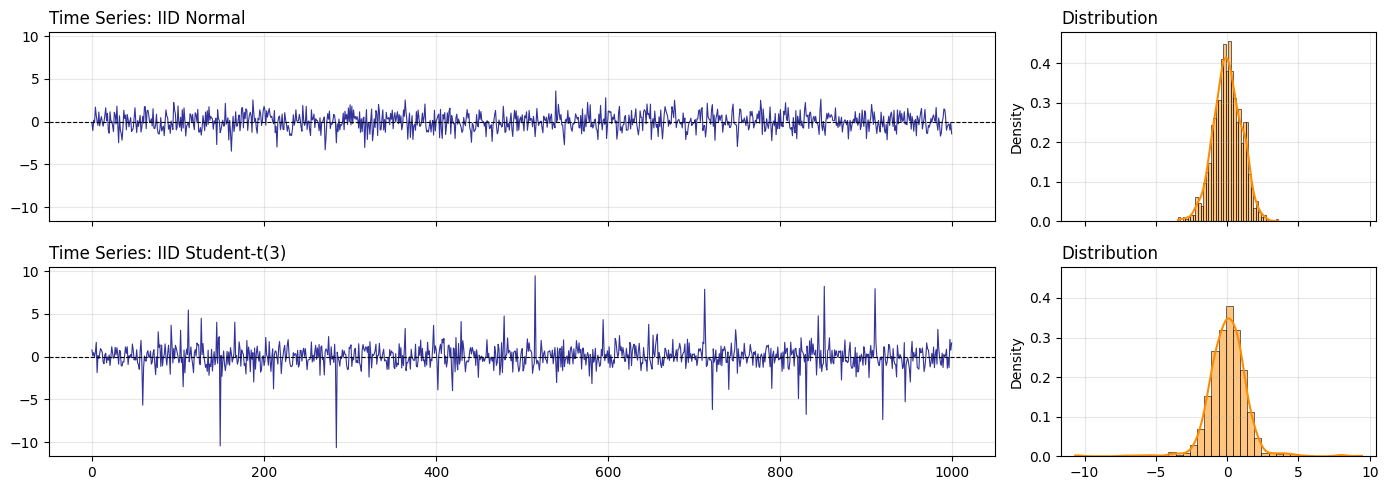

In [6]:

specs = [
    TrajectorySpec(IIDProcess(NormalInnov()),          
                   name="IID Normal", n=1, length=1000),
    TrajectorySpec(WithOutliers(IIDProcess(NormalInnov()), fraction=0.05),    
                   name="IID Student-t(3)", n=1, length=1000),
]

# 2. Generate the data
gen = SyntheticGenerator(seed=42)
df = gen.generate(specs)


plot_series(df)